# Class 22: Partial Differential Equations Part 2

Ch. 9, sections 3: Partial Differential Equations  
- Initial value problems
    - the FTCS method 

Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random 

### Initial Value Partial Differential Equations Problems: the FTCS method

**Example 9.3**: The Heat Equation 

The flat base of a container made of 1 cm thick stainless steel is initially at a uniform temperature of $20^\circ$ C everywhere. The container is placed in a bath of cold water at $0^\circ$ C and filled with hot water at $50^\circ$ C. 

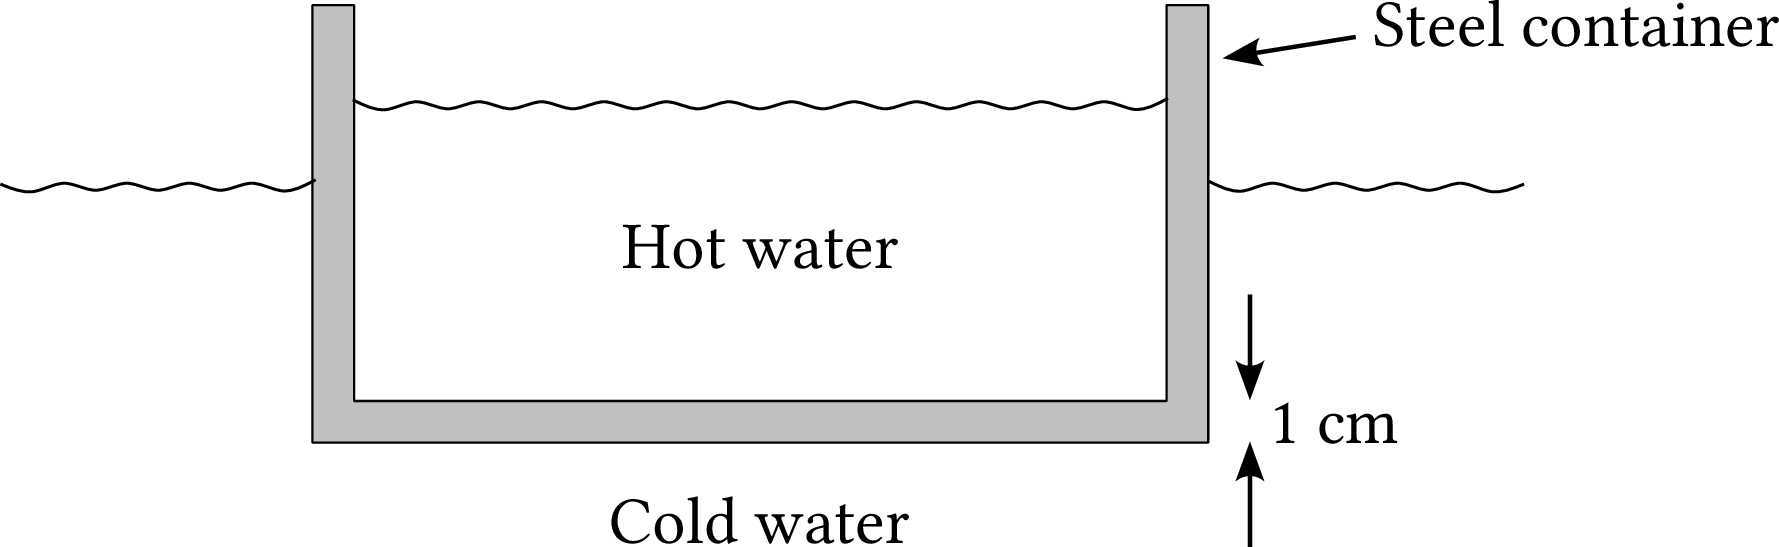

Our goal is to calculate the temperature profile of the steel as a function of distance $x$ from the hot side to the cold side, and as a function of time. For simplicity, let's treat the base of the container as being arbitrarily wide, so that its temperature profile is the same everywhere, and assume that neither the hot nor the cold water changes temperature appreciably. 

Thermal conduction is goverened by the diffusion equation, so solving this problem is a matter of solving the one-dimensional diffusion equation for the temperature $T$: 

$$ \frac{\partial T}{\partial t} = D \frac{\partial^2 T}{\partial x^2} $$

where $T$ is the temperature and $D$ is the heat diffusion coefficient, also called the thermal diffusivity. Let us divide the $x$-axis into 200 equal grid intervals, meaning that there will be 201 grid points in total, counting the first and last ones. The first and last points have fixed temperatures of $50^\circ$ C and $0^\circ$ C, respectively, while the intermediate points are initially all at $20^\circ$ C. We also need the heat diffusion coefficient for stainless steel (thermal diffusivity), which is $D = 4.25 \times 10^{-6}$ $\text{ m}^2\text{s}^{-1}$. 

We will calculate this using the FTCS method, and plot the temperature profile at times $t = 0.01, 0.1, 0.4, 1.0,$ and $10.0$ s all on the same graph. 

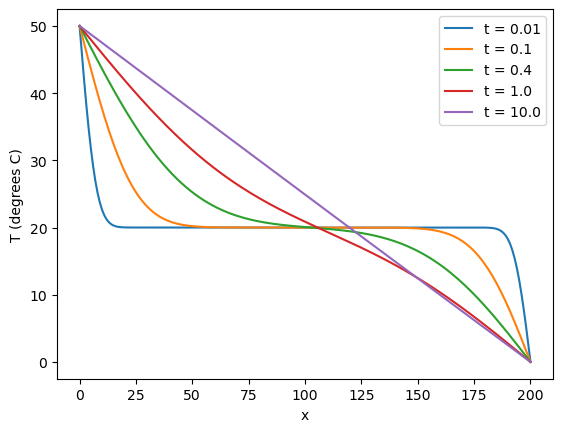

In [3]:
# constants 
D = 4.25e-6     # thermal diffusivity 
N = 200         # number of divisions in grid
L = 0.01        # thickness of steel in meters 
a = L/N         # grid spacing 
h = 1e-4        # time-step 

# temperatures 
Tlow = 0.0
Thi = 50.0
Tmid = 20.0

# create arrays 
T = np.ones(N+1, float)*Tmid
T[0] = Thi
T[-1] = Tlow
Tp = np.ones(N+1, float)*Tmid
Tp[0] = Thi
Tp[-1] = Tlow

# times of interest
t1 = 0.01
t2 = 0.1
t3 = 0.4
t4 = 1.0
t5 = 10.0
epsilon = h/1000
tend = t5 + epsilon 

# execute the FTCS method 
t = 0.0
const = h*D/a**2
while t < tend: 
    # calculate the new value of T
    #for i in range(1,N): 
    #    Tp[i] = T[i] + const*(T[i+1]+T[i-1]-2*T[i])
    Tp[1:N] = T[1:N] + const*(T[2:N+1]+T[0:N-1]-2*T[1:N])
    T, Tp = Tp, T
    t += h

    # make plots at specific times 
    if np.abs(t-t1) < epsilon:
        plt.plot(T)
    if np.abs(t-t2) < epsilon:
        plt.plot(T)
    if np.abs(t-t3) < epsilon:
        plt.plot(T)
    if np.abs(t-t4) < epsilon:
        plt.plot(T)
    if np.abs(t-t5) < epsilon:
        plt.plot(T)
plt.legend(["t = "+str(t1), "t = "+str(t2), "t = "+str(t3), "t = "+str(t4), "t = "+str(t5)])
plt.ylabel("T (degrees C)")
plt.xlabel("x")
plt.show()

### Exercise 9.8: Thermal diffusion in the Earth's Crust

A classic example of a diffusion problem with a time-varying boundary condition is the diffusion of heat into the crust of the Earth, as surface temperature varies with the seasons. Suppose the mean daily temperature at a particular point on the surface varies as:

$$ T_0(t) = A + B\sin{\frac{2\pi t}{\tau}} $$

where $\tau = 365$ days, $A = 10^{\circ}\text{C}$ and $B = 12^{\circ}\text{C}$. At a depth of $20$ m below the surface almost all annual temperature variation is ironed out and the temperature is, to a good approximation, a constant $11^{\circ}\text{C}$ (which is higher than the mean surface temperature of $10^{\circ}\text{C}$—temperature increases with depth, due to heating from the hot core of the planet). The thermal diffusivity of the Earth’s crust varies somewhat from place to place, but for our purposes we will treat it as constant with value $D = 0.1\text{ m}^2\text{ day}^{−1}$.

Write a program, or modify one of the ones given in this chapter, to calculate the temperature profile of the crust as a function of depth up to $20$ m and time up to $10$ years. Start with temperature everywhere equal to $10^{\circ}\text{C}$, except at the surface and the deepest point, choose values for the number of grid points and the time-step $h$, then run your program for the first nine simulated years, to allow it to settle down into whatever pattern it reaches. Then for the tenth and final year plot four temperature profiles taken at 3-month intervals on a single graph to illustrate how the temperature changes as a function of depth and time.

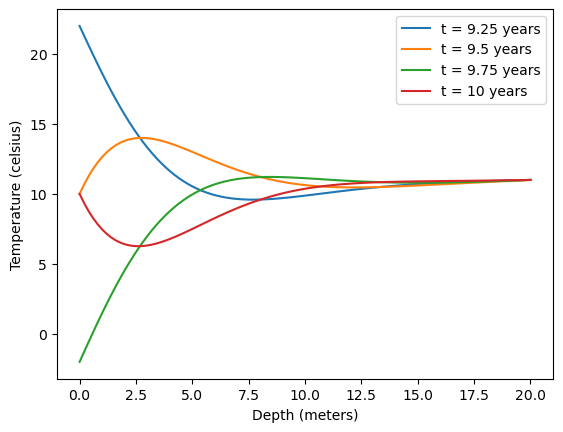

In [4]:
# define constants
L = 20.0        # length of system 
N = 100         # number of spatial points 
a = L/N         # point separation 
h = 0.01        # time spacing in days 
D = 0.1         # thermal diffusivity of the crust


A = 10.0        # constants for sinusoidal variation 
B = 12.0
tau = 365
Tfixed = 11.0   # temperature at the bottom 

tmax = 10.01*365
steps = int(tmax/h)

# desired time intervals 
s1 = int(9.25*365/h)
s2 = int(9.50*365/h)
s3 = int(9.75*365/h)
s4 = int(10.0*365/h)

# setup initial conditions 
T = np.zeros(N+1, float)
T[0:N] = A
T[N] = Tfixed

# loop to do FTCS solution 
x = np.linspace(0.0,L,N+1)
for k in range(steps):
    t = k*h
    T[0] = A + B*np.sin(2*np.pi*t/tau)
    T[1:N] += h*D*(T[0:N-1]+T[2:N+1]-2*T[1:N])/a**2
    if k==s1 or k==s2 or k==s3 or k==s4:
        plt.plot(x,T)

plt.xlabel("Depth (meters)")
plt.ylabel("Temperature (celsius)")
plt.legend(["t = "+str(9.25)+" years", "t = "+str(9.50)+" years", "t = "+str(9.75)+" years", "t = "+str(10)+" years"])
plt.show()



### Exercise 9.4: Laplace's Equation in an irregular space

Let us solve for the electric potential inside a trapezoidal space like this:

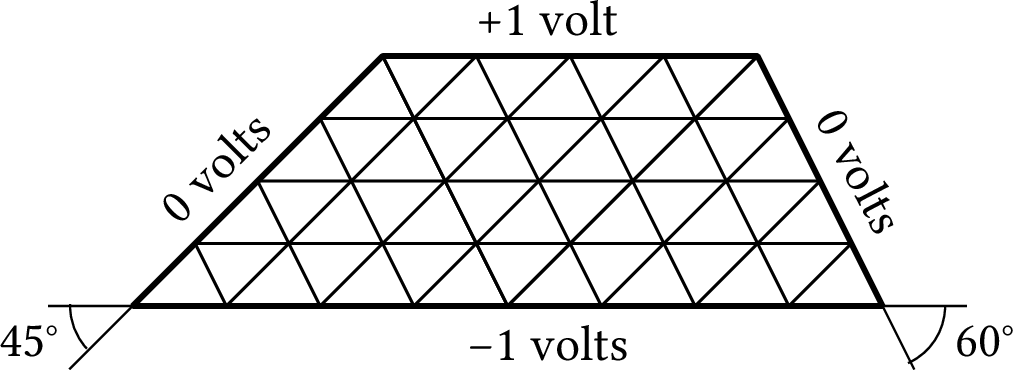

with voltages on the walls as indicated.  We triangulate the space as shown, with $M$ triangles along the top and side edges and $2M$ triangles along the bottom, where $M=4$ in the figure.

**(a)** Calculate the matrix elements $L_{ij}$, Eq. (9.18), for all pairs $i,j$ of adjacent points as well as the diagonal elements $L_{ii}$.

**(b)** Write a program to solve for the electric potential on all grid points for the case $M=4$.  You will have to choose a scheme for storing the field values $\phi_i$.  There are various possibilities, but perhaps the simplest is to just store the rows of grid points in a two-dimensional array.  Not all rows have the same length, but if you don't mind wasting a little memory space you can just make the array large enough to store the longest row (which has $2M+1$ grid points).

Now write code to perform the Jacobi iteration and compute the electric potential.  You can use the program from Example 9.1 on page 403 as a starting point if you wish.  Continue the iteration until your solution changes by less than $10^{-6}\text{ V}$ per step at every grid point.


**(c)** Add code to your program to visualize the solution.  The simplest way to do this is just to make a density plot of the array holding the values $\phi_i$.  This will produce a picture with extra non-functional grid points at the end of each row, and the angles on the grid will not be correct.  Alternatively you could compute the actual location of each grid point in two-dimensional space and then visualize the value of $\phi_i$ at each point by, for example, plotting a circle of an appropriate color, which can be done using the `scatter` function in `pyplot`.  For a more sophisticated approach, take a look at the function `meshplot`, which can be found in Appendix C, Section C.4, and also in the file `meshplot.py` in the online resources, which makes a true density plot of the data on a triangulation.

**(d)** Once you have your program working, increase the size of the system to $M=100$ and rerun the calculation to produce a final, high-resolution picture of the solution.


*note* we don't care about the 4 or denominator of the equation for non-square grids due to the Laplacian equaling 0

0.4273968269096606
0.18266804765244637
0.0870833560220664
0.07828983448826993
0.05266044063598592
0.04495307718684166
0.03749755986533315
0.030132191599876346
0.028517818734766776
0.023794316723166786
0.022739262639066338
0.019945429124960223
0.01874216143854024
0.017323433332735838
0.0160587056402276
0.015273840183095855
0.014307114245896646
0.013584650466331727
0.012812444842552062
0.012175259555153861
0.011539968925544652
0.010986513103806828
0.01046353050321952
0.010063330395501557
0.009694873859914355
0.009338521283150825
0.009005921783899584
0.008687430901179682
0.008387886088365437
0.008102309100841698
0.007832471038147548
0.007575615367336197
0.00733215837326584
0.007100433576918641
0.006891750137981545
0.006715161199420949
0.006544858833576472
0.006380828205000966
0.006222706857172189
0.006070365570257752
0.005923513735068497
0.005781975474822398
0.005645502322901619
0.00551390470478208
0.00538696278666323
0.005264489133492534
0.005146286123513477
0.0050321757794865585
0.00492

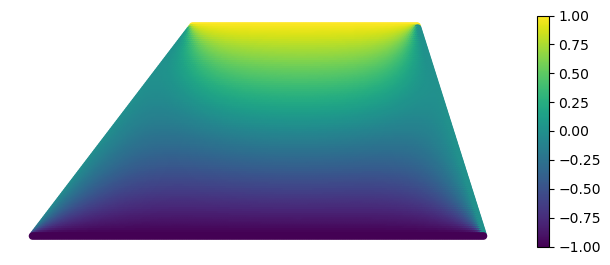

In [5]:
# constants 
L = 100
theta = np.array([75,60,45], float) * np.pi/180
cot = 1/np.tan(theta)
w = 0.5*cot/sum(cot)
Vtop, Vbottom = +1.0, -1.0
target = 1e-6 # target accuracy 
ax, ay = 1.0, 1/np.sqrt(2.0)

# function to calculate the actual location of point i,j
def calc_loc(i,j): 
    return j*ax-i*ay, (L-i)*ay

# array to hold values 
phi = np.zeros([L+1, 2*L+1], float)
phiprime = np.zeros([L+1, 2*L+1], float)
phi[0,:] = Vtop
phi[-1,:] = Vbottom 
phiprime[0,:] = Vtop
phiprime[-1,:] = Vbottom 

# main loop 
delta = 1.0
while delta > target: 
    # go through interior points 
    for i in range(1,L): 
        for j in range(1,i+L):
            phiprime[i,j] = w[0]*(phi[i,j-1]+phi[i,j+1])+w[1]*(phi[i-1,j]+phi[i+1,j])+w[2]*(phi[i-1,j-1]+phi[i+1,j+1])

    # calculate maximum different from old values 
    delta = np.max(np.abs(phi-phiprime))
    print(delta)

    # swap two arrays 
    phi, phiprime = phiprime, phi

# make visualization 
xpoints = []
ypoints = []
color = []
for i in range(0,L+1): 
    for j in range(1,i+L+1): 
        x,y = calc_loc(i,j)
        xpoints.append(x)
        ypoints.append(y)
        color.append(phi[i,j])

# visualize 
plt.figure(figsize=(8, 3))
plt.scatter(xpoints, ypoints, c=color, s=20)
plt.axis("off")
plt.colorbar()
plt.show()